In [2]:
import emodeconnection as emc
import numpy as np
import matplotlib.pyplot as plt
import time


# Fixed parameters of Geometry
wavelength_fund = 450.0
w_core = 400.0  # [nm] Fixed width
h_core = 350.0  # [nm] Fixed height
dx, dy = 10.0, 10.0


# Sellmeier Material Definition
# Use double asterisks for power, ensure no spaces in the inner math, and verify the negative B3/C3 values are handled cleanly.
eq_o = '(1+2.8032/(1-0.015287/x**2)+0.36335/(1-0.036095/x**2)-33508000/(1+367200000/x**2))**0.5'
eq_e = '(1+0.017061/(1-0.043855/x**2)+3.1976/(1-0.022642/x**2)-57269000/(1-74226000/x**2))**0.5'
anisotropic_equation = f"[{eq_o},{eq_e},{eq_o}]"

In [ ]:
em.close()

In [4]:
# Launch EMode 
em = emc.EMode(simulation_name='example_AlN_waveguide_sweep1')



In [5]:
# Set Up Simulation
em.add_material(name='custom_AlN',                                  
                refractive_index_equation=anisotropic_equation, 
                wavelength_unit='um')
em.settings(window_width=2000,window_height=h_core+2000, boundary_condition='TM') # Using your 'TM' preference)
em.shape(name='Substrate', material='Al2O3', height=1000)
em.shape(name='core', material='custom_AlN', height=h_core, mask=w_core, etch_depth=h_core, sidewall_angle=5)
em.shape(name='TopClad', material='SiO2', height=800, shape_type='conformal')
em.plot()


'ok'

In [15]:
# Calculate Modes for FUNDAMENTAL WAVELENGTH
Nmodes_to_calculate = 10
em.settings(wavelength=wavelength_fund, x_resolution=dx, y_resolution=dy,window_width=2000,
            window_height=h_core+2000, num_modes=Nmodes_to_calculate, boundary_condition='TM') # Using your 'TM' preference)
em.FDM()                            #run the finite difference mode solver to find the modes of the structure
em.confinement(shape_list='core')   #calculate the confinement factor for each mode
em.report()                         #print information about the calculation results to command line
em.label_profile(name = 'dataset1') #store this set of results under label '0'
em.plot()


'ok'

In [ ]:
## Run wavelength sweep:  FUNDAMENTAL WAVELENGTH
wav_nm = np.arange(400, 500, 10)
data = em.sweep(key = 'wavelength', values = wav_nm,
    result = ['effective_index','mode_order'])
em.save(simulation_name='example_AlN_waveguide_sweep1.eph')  # Save the simulation state to a fileem.save(simulation_name='example_AlN_waveguide_copy.eph')  # Save the simulation state to a file

'ok'

In [18]:
print(data['mode_order'])


None


In [ ]:
neff_matrix = np.array(data['effective_index'])

#Create the plot
plt.figure(figsize=(10, 6), dpi=100)

# Option A: Plot all modes found in the sweep
num_modes_found = neff_matrix.shape[1]
for i in range(num_modes_found):
    plt.plot(wav_nm, neff_matrix[:, i], '-o', label=f'Mode {i+1}')

# 3. Formatting the chart
plt.title(f'Wavelength Sweep: Effective Index vs. Wavelength\n({w_core}nm x {h_core}nm AlN Core)', fontsize=12)
plt.xlabel('Wavelength (nm)', fontsize=11)
plt.ylabel('Effective Index (n_eff)', fontsize=11)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='best')

# 4. Display or save
plt.tight_layout()
plt.show()

In [11]:
print(wavelength_fund/2)

225.0


In [19]:
# Calculate Modes for SECOND HARMONIC WAVELENGTH
Nmodes_to_calculate = 40
em.settings(num_modes=Nmodes_to_calculate, wavelength=wavelength_fund/2, x_resolution=dx/2, y_resolution=dy/2, max_effective_index=2.6)
em.FDM()                            #run the finite difference mode solver to find the modes of the structure
em.confinement(shape_list='core')   #calculate the confinement factor for each mode
em.report()                         #print information about the calculation results to command line
em.label_profile(name = 'dataset2') #store this set of results under label 'dataset2'
em.plot()

'ok'

In [20]:
em.plot()

'ok'

In [ ]:
## Run wavelength sweep:  SECOND HARMONIC WAVELENGTH
wav2_nm = np.arange(400, 500, 10)/2
data2 = em.sweep(key = 'wavelength',                        #which parameter to sweep
                 values = wav2_nm,                          #values to sweep over
                 result = ['effective_index','mode_order']) #which results to return for each sweep step
em.save(simulation_name='example_AlN_waveguide_sweep1.eph')  # Save the simulation state to a fileem.save(simulation_name='example_AlN_waveguide_copy.eph')  # Save the simulation state to a file

'ok'

In [25]:
neff2_array = np.array(data2['effective_index'])
np.size(neff2_array)
print(data2['mode_order'])

None


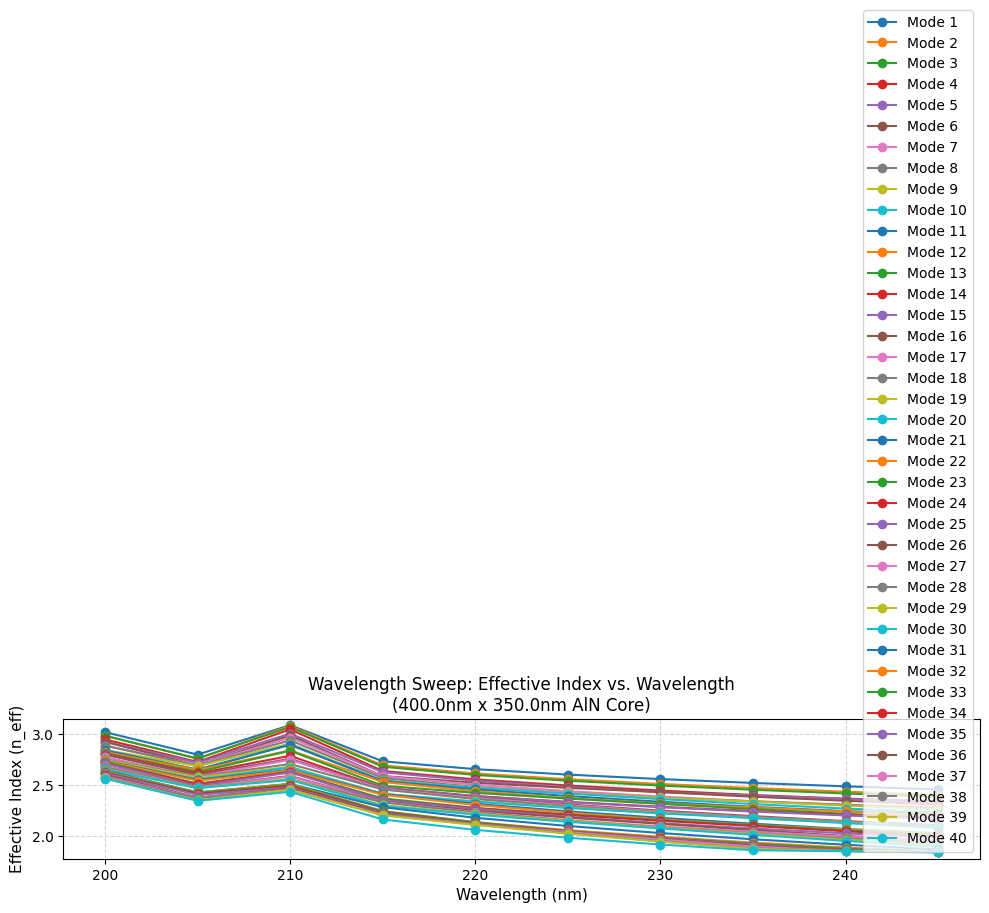

In [12]:
neff2_matrix = np.array(data2['effective_index'])

#Create the plot
plt.figure(figsize=(10, 6), dpi=100)

# Option A: Plot all modes found in the sweep
num_modes_found = neff2_matrix.shape[1]
for i in range(num_modes_found):
    plt.plot(wav2_nm, neff2_matrix[:, i], '-o', label=f'Mode {i+1}')

# 3. Formatting the chart
plt.title(f'Wavelength Sweep: Effective Index vs. Wavelength\n({w_core}nm x {h_core}nm AlN Core)', fontsize=12)
plt.xlabel('Wavelength (nm)', fontsize=11)
plt.ylabel('Effective Index (n_eff)', fontsize=11)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='best')

# 4. Display or save
plt.tight_layout()
plt.show()

In [ ]:
# Example: Wavelength in col 1, Neff in col 2
data_to_export = np.column_stack((wav2_nm, neff2_matrix[:, :]))

# Save with a header
np.savetxt(
    'AlN_Sweep_Results.csv',           # Filename
    data_to_export,                    # The array
    delimiter=',',                    # Use commas for CSV
    header='Wavelength_nm,n_eff_TE00', # Column titles
    comments=''
)

In [ ]:
em.close()